# Aerial Object Classification & Detection

**Step 1: Setup & Suppress Warnings**

In [2]:
import warnings
import logging
import os

# avoid  warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("Warnings are now suppressed. You can proceed with your project!")

Warnings are now suppressed. You can proceed with your project!


**Step 2- Understand the Dataset**

------------------------------
Class-wise Image Counts:
------------------------------
bird: 1414 images
drone: 1248 images


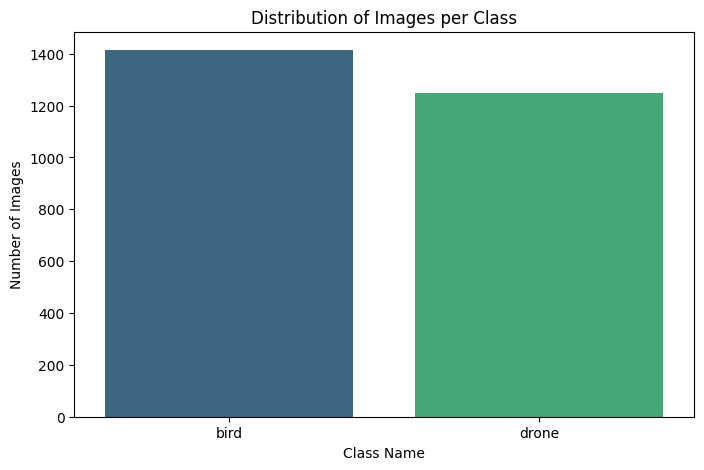

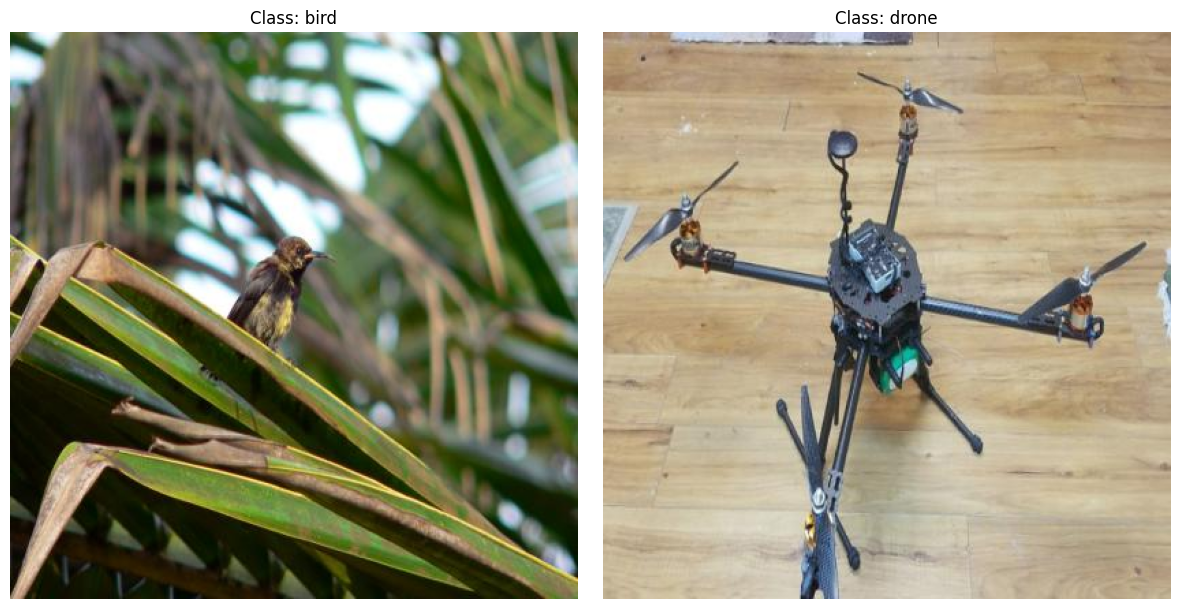

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 1. Paths 
train_dir = '/kaggle/input/datasets/devahaasan/aerial-dataset/train-20260324T055231Z-1-001/train'

# 2. Inspect folder structure and count images per class
classes = os.listdir(train_dir)
image_counts = {}

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        image_counts[cls] = count

# Display class counts
print("-" * 30)
print("Class-wise Image Counts:")
print("-" * 30)
for cls, count in image_counts.items():
    print(f"{cls}: {count} images")

# 3. Check for Class Imbalance (Visualizing with a Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette='viridis')
plt.title('Distribution of Images per Class')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.show()

# 4. Visualize Sample Images from each class
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        img_name = os.listdir(class_path)[0] # First image in folder
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(f"Class: {cls}")
        plt.axis('off')

plt.tight_layout()
plt.show()

**Step 3: Data Preprocessing**

In [4]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Exact paths based on your dataset structure
train_dir = '/kaggle/input/datasets/devahaasan/aerial-dataset/train-20260324T055231Z-1-001/train'
valid_dir = '/kaggle/input/datasets/devahaasan/aerial-dataset/valid-20260324T055218Z-1-001/valid'
test_dir = '/kaggle/input/datasets/devahaasan/aerial-dataset/test-20260324T055245Z-1-001/test'

# Normalize pixel values to [0, 1]
# model-specific preprocessing if using Transfer Learning
preprocess_datagen = ImageDataGenerator(rescale=1./255)

print("Data Preprocessing initialized...")

E0000 00:00:1774785145.634391      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774785145.700857      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774785146.215708      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774785146.215746      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774785146.215749      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774785146.215752      55 computation_placer.cc:177] computation placer already registered. Please check linka

Data Preprocessing initialized...


**Step 4: Data Augmentation**

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Image Settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Data Augmentation for Training Set (Apply transformations)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalizing (Step 2)
    rotation_range=30,        # Rotate image randomly up to 30 degrees
    width_shift_range=0.2,    # Shift image horizontally
    height_shift_range=0.2,   # Shift image vertically
    shear_range=0.2,          # Apply shear transformation
    zoom_range=0.2,           # Zoom in/out randomly
    horizontal_flip=True,     # Flip image horizontally
    fill_mode='nearest'       # Fill empty pixels after rotation
)

# 3. Validation and Test Set (Only Normalization, NO Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 4. Creating Generators to load images from the folders
print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/datasets/devahaasan/aerial-dataset/train-20260324T055231Z-1-001/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nLoading Validation Data...")
valid_generator = val_test_datagen.flow_from_directory(
    '/kaggle/input/datasets/devahaasan/aerial-dataset/valid-20260324T055218Z-1-001/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nLoading Test Data...")
test_generator = val_test_datagen.flow_from_directory(
    '/kaggle/input/datasets/devahaasan/aerial-dataset/test-20260324T055245Z-1-001/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n--- Data Augmentation & Generators are ready! ---")

Loading Training Data...
Found 2662 images belonging to 2 classes.

Loading Validation Data...
Found 442 images belonging to 2 classes.

Loading Test Data...
Found 215 images belonging to 2 classes.

--- Data Augmentation & Generators are ready! ---


**Step 5: Model Building (Classification)**

**ResNet50, MobileNetV2,EfficientNetB0**

In [6]:
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras import layers, models

def build_transfer_model(base_arch):
    # 1. Load the pre-trained model with ImageNet weights
    if base_arch == 'resnet':
        base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    elif base_arch == 'mobilenet':
        base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    elif base_arch == 'efficientnet':
        base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    
    # 2. Freeze the base model (We will unfreeze later for Fine-tuning)
    base_model.trainable = False 
    
    # 3. Build the classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid') # Binary: Bird vs Drone
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Creating the 3 models
resnet_model = build_transfer_model('resnet')
mobilenet_model = build_transfer_model('mobilenet')
efficientnet_model = build_transfer_model('efficientnet')

print("--- Step 4: ResNet50, MobileNetV2, and EfficientNetB0 are ready! ---")

I0000 00:00:1774785190.972100      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774785190.978176      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Step 4: ResNet50, MobileNetV2, and EfficientNetB0 are ready! ---


**Step 6: Model Training**

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1.  Callbacks 
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# --- MobileNetV2 training ---
print("\n--- Training MobileNetV2 ---")
checkpoint_mobile = ModelCheckpoint('best_mobilenet.h5', monitor='val_accuracy', save_best_only=True)
history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10, 
    callbacks=[early_stop, checkpoint_mobile]
)

# --- ResNet50 training ---
print("\n--- Training ResNet50 ---")
checkpoint_resnet = ModelCheckpoint('best_resnet.h5', monitor='val_accuracy', save_best_only=True)
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint_resnet]
)

# --- EfficientNetB0 training ---
print("\n--- Training EfficientNetB0 ---")
checkpoint_eff = ModelCheckpoint('best_efficientnet.h5', monitor='val_accuracy', save_best_only=True)
history_eff = efficientnet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint_eff]
)

print("\n--- Step 5: All 3 Models are Trained Successfully! ---")


--- Training MobileNetV2 ---
Epoch 1/10


I0000 00:00:1774785213.588819     150 service.cc:152] XLA service 0x793938010720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774785213.588862     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774785213.588866     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774785214.842805     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774785226.523088     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.8758 - loss: 0.2777

84/84 ━━━━━━━━━━━━━━━━━━━━ 90s 853ms/step - accuracy: 0.8764 - loss: 0.2766 - val_accuracy: 0.9751 - val_loss: 0.0748
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 409ms/step - accuracy: 0.9667 - loss: 0.0850 - val_accuracy: 0.9661 - val_loss: 0.0781
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9609 - loss: 0.0920

84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 404ms/step - accuracy: 0.9610 - loss: 0.0918 - val_accuracy: 0.9796 - val_loss: 0.0719
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 397ms/step - accuracy: 0.9800 - loss: 0.0539 - val_accuracy: 0.9706 - val_loss: 0.1010
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 396ms/step - accuracy: 0.9734 - loss: 0.0535 - val_accuracy: 0.9706 - val_loss: 0.1102
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9848 - loss: 0.0391

...

84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 421ms/step - accuracy: 0.7810 - loss: 0.4873 - val_accuracy: 0.8190 - val_loss: 0.4233
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 474ms/step - accuracy: 0.7868 - loss: 0.4524 - val_accuracy: 0.7896 - val_loss: 0.4517
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 482ms/step - accuracy: 0.7796 - loss: 0.4561 - val_accuracy: 0.7941 - val_loss: 0.4204
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 49s 582ms/step - accuracy: 0.7782 - loss: 0.4389 - val_accuracy: 0.7919 - val_loss: 0.4440
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 529ms/step - accuracy: 0.7865 - loss: 0.4481 - val_accuracy: 0.8009 - val_loss: 0.4714

--- Training EfficientNetB0 ---
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.4960 - loss: 1.0065

84/84 ━━━━━━━━━━━━━━━━━━━━ 92s 806ms/step - accuracy: 0.4961 - loss: 1.0061 - val_accuracy: 0.5090 - val_loss: 0.7045
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 412ms/step - accuracy: 0.5415 - loss: 0.8635 - val_accuracy: 0.5090 - val_loss: 0.6889
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.5123 - loss: 0.8504

84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 414ms/step - accuracy: 0.5124 - loss: 0.8499 - val_accuracy: 0.5113 - val_loss: 0.6902
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 403ms/step - accuracy: 0.5618 - loss: 0.7470 - val_accuracy: 0.5113 - val_loss: 0.6881
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 410ms/step - accuracy: 0.5267 - loss: 0.7588 - val_accuracy: 0.5113 - val_loss: 0.6883
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5582 - loss: 0.7293

84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 433ms/step - accuracy: 0.5581 - loss: 0.7293 - val_accuracy: 0.5452 - val_loss: 0.6872
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 484ms/step - accuracy: 0.5757 - loss: 0.7116 - val_accuracy: 0.5113 - val_loss: 0.6862
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 455ms/step - accuracy: 0.5409 - loss: 0.7100 - val_accuracy: 0.5136 - val_loss: 0.6856
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.5519 - loss: 0.6948

84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 449ms/step - accuracy: 0.5519 - loss: 0.6947 - val_accuracy: 0.6855 - val_loss: 0.6810
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 444ms/step - accuracy: 0.5688 - loss: 0.6880 - val_accuracy: 0.6674 - val_loss: 0.6790

--- Step 5: All 3 Models are Trained Successfully! ---


**Step 7: Model Comparison and Evaluation**

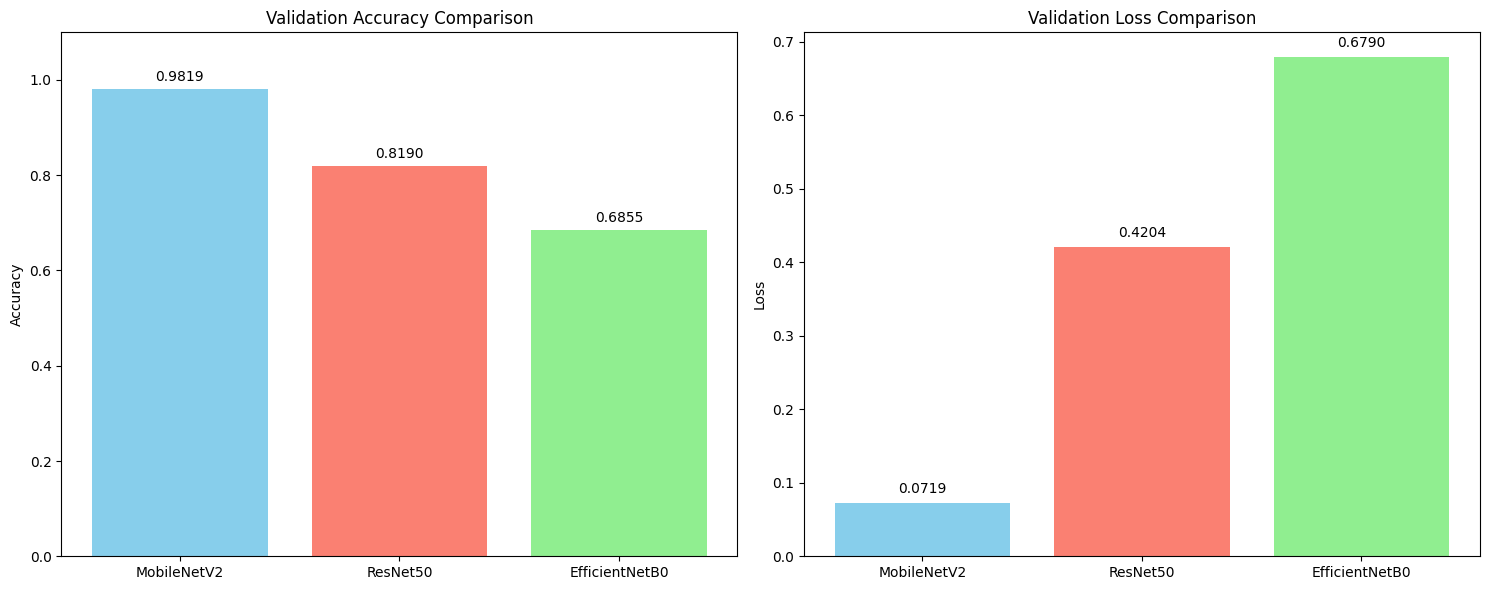

--- Final Comparison Summary ---
Best Performing Model: MobileNetV2
Highest Accuracy: 0.9819
Lowest Loss: 0.0719


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Collect the best validation accuracy and lowest validation loss for each model
models_names = ['MobileNetV2', 'ResNet50', 'EfficientNetB0']

# Getting the best values from history objects
acc_values = [
    max(history_mobile.history['val_accuracy']),
    max(history_resnet.history['val_accuracy']),
    max(history_eff.history['val_accuracy'])
]

loss_values = [
    min(history_mobile.history['val_loss']),
    min(history_resnet.history['val_loss']),
    min(history_eff.history['val_loss'])
]

# 2. Plotting Comparison Graphs
plt.figure(figsize=(15, 6))

# Plot Accuracy Comparison
plt.subplot(1, 2, 1)
bars_acc = plt.bar(models_names, acc_values, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Validation Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
# Adding labels on top of bars
for bar in bars_acc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

# Plot Loss Comparison
plt.subplot(1, 2, 2)
bars_loss = plt.bar(models_names, loss_values, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Validation Loss Comparison')
plt.ylabel('Loss')
# Adding labels on top of bars
for bar in bars_loss:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 3. Print Final Conclusion
best_idx = np.argmax(acc_values)
print(f"--- Final Comparison Summary ---")
print(f"Best Performing Model: {models_names[best_idx]}")
print(f"Highest Accuracy: {acc_values[best_idx]:.4f}")
print(f"Lowest Loss: {loss_values[best_idx]:.4f}")

 **Step 8: MobileNetV2 -Cross-Validation**

In [9]:
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import KFold 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Paths and Parameters

train_dir = '/kaggle/input/datasets/devahaasan/aerial-dataset/train-20260324T055231Z-1-001/train'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
KFOLDS = 5 

# 2. Prepare Data List
data = []
for category in ['bird', 'drone']:
    folder_path = os.path.join(train_dir, category)
    for img in os.listdir(folder_path):
        data.append({'filename': os.path.join(folder_path, img), 'label': category})

df = pd.DataFrame(data)

# 3. K-Fold Cross Validation Setup
kf = KFold(n_splits=KFOLDS, shuffle=True, random_state=42)
datagen = ImageDataGenerator(rescale=1./255)

fold_no = 1
accuracies = []

for train_idx, val_idx in kf.split(df):
    print(f"\n--- Training Fold {fold_no} ---")
    
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    train_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='label',
                                            target_size=IMG_SIZE, class_mode='binary', 
                                            batch_size=BATCH_SIZE, verbose=0)
    
    val_gen = datagen.flow_from_dataframe(val_df, x_col='filename', y_col='label',
                                          target_size=IMG_SIZE, class_mode='binary', 
                                          batch_size=BATCH_SIZE, verbose=0)
    
    # Build MobileNetV2 for each fold
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Training for 3 epochs (to save time during cross-validation)
    history = model.fit(train_gen, validation_data=val_gen, epochs=3, verbose=1)
    
    fold_acc = max(history.history['val_accuracy'])
    accuracies.append(fold_acc)
    print(f"Fold {fold_no} Accuracy: {fold_acc:.4f}")
    fold_no += 1

# 4. Final Results
print("\n" + "="*30)
print(f"Average CV Accuracy: {np.mean(accuracies):.4f}")
print(f"Standard Deviation: {np.std(accuracies):.4f}")
print("="*30)


--- Training Fold 1 ---
Found 2129 validated image filenames belonging to 2 classes.
Found 533 validated image filenames belonging to 2 classes.
Epoch 1/3
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 523ms/step - accuracy: 0.7870 - loss: 0.4417 - val_accuracy: 0.9456 - val_loss: 0.1735
Epoch 2/3
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9433 - loss: 0.1541 - val_accuracy: 0.9531 - val_loss: 0.1229
Epoch 3/3
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9719 - loss: 0.1034 - val_accuracy: 0.9587 - val_loss: 0.0996
Fold 1 Accuracy: 0.9587

--- Training Fold 2 ---
Found 2129 validated image filenames belonging to 2 classes.
Found 533 validated image filenames belonging to 2 classes.
Epoch 1/3
67/67 ━━━━━━━━━━━━━━━━━━━━ 27s 281ms/step - accuracy: 0.7126 - loss: 0.5365 - val_accuracy: 0.9531 - val_loss: 0.1700
Epoch 2/3
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9523 - loss: 0.1542 - val_accuracy: 0.9700 - val_loss: 0.1138
Epoch 3/3
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/s

**Step 9: Model save**

In [10]:
# Save the model in the  Keras format
model.save('aerial_mobilenet_final.keras')

print("✅ Final Model Saved Successfully in Native Keras Format!")

✅ Final Model Saved Successfully in Native Keras Format!


In [12]:
model.save('Aerial_mobilenet_final.h5')

print("✅ Final Model Saved Successfully!")

✅ Final Model Saved Successfully!
